# ✈️ Airline Customer Feedback Analysis & Automated Response



This project uses Python to find serious negative airline reviews and help the customer-support team respond to them.

The workflow:

**Load data → Clean data → Find critical reviews → Find common complaints → Select 3 detailed cases → Generate AI responses**

The critical-review filtering is **rule-based** and does not use Machine Learning, as required by the assessment.

## 1. What this project does

Airlines receive many customer reviews, so reading every review manually can take a lot of time.

In this project, I use Python to:

- prepare the review data
- clean the review text
- convert the dataset's rating into a simple 1–5 scale
- identify critical reviews using a clear rule
- find common complaint keywords
- group related complaints into categories
- select three detailed critical reviews
- use Google Gemini to draft short, personalized apology emails

The goal is not to replace customer-support staff. The goal is to help them find important cases faster and reduce repetitive writing work.

## 2. Import the required libraries

I will use Pandas for data handling, NumPy for simple calculations, regular expressions for text cleaning, `Counter` for complaint counting, and Matplotlib for a small visualization.

In [56]:
import os
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Load the dataset

The dataset used for this project is `Airline_review.csv`.

Keep the CSV file in the **same folder as this Jupyter Notebook** before running the notebook.

In [57]:
DATA_PATH = Path("Airline_review.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Airline_review.csv was not found. "
        "Place the CSV file in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 23,171
Columns: 20


,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


## 4. Understand the dataset

Before cleaning anything, I will check the column names, data types, missing values, and duplicate rows.

This helps me understand what needs to be cleaned before doing the actual analysis.

In [58]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title', 'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller', 'Seat Type', 'Route', 'Date Flown', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Ground Service', 'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money', 'Recommended']


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  str    
 2   Overall_Rating          23171 non-null  str    
 3   Review_Title            23171 non-null  str    
 4   Review Date             23171 non-null  str    
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  str    
 7   Aircraft                7129 non-null   str    
 8   Type Of Traveller       19433 non-null  str    
 9   Seat Type               22075 non-null  str    
 10  Route                   19343 non-null  str    
 11  Date Flown              19417 non-null  str    
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null  float64
 

In [60]:
missing_values = df.isnull().sum().sort_values(ascending=False)

display(
    missing_values[missing_values > 0]
    .to_frame("Missing_Values")
)

,Missing_Values
Wifi & Connectivity,17251
Aircraft,16042
Inflight Entertainment,12342
Food & Beverages,8671
Ground Service,4793
Cabin Staff Service,4260
Seat Comfort,4155
Route,3828
Date Flown,3754
Type Of Traveller,3738


In [61]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 5. Keep the columns needed for this project

The assessment mainly needs customer ratings and review text.

I will keep the airline name, overall rating, review title, and review content. The other columns are useful in the original dataset, but they are not necessary for this assessment.

In [62]:
df = df[
    [
        "Airline Name",
        "Overall_Rating",
        "Review_Title",
        "Review"
    ]
].copy()

display(df.head())

,Airline Name,Overall_Rating,Review_Title,Review
0,AB Aviation,9,"""pretty decent airline""",Moroni to Moheli. Turned out to be a pretty ...
1,AB Aviation,1,"""Not a good airline""",Moroni to Anjouan. It is a very small airline...
2,AB Aviation,1,"""flight was fortunately short""",Anjouan to Dzaoudzi. A very small airline an...
3,Adria Airways,1,"""I will never fly again with Adria""",Please do a favor yourself and do not fly wi...
4,Adria Airways,1,"""it ruined our last days of holidays""",Do not book a flight with this airline! My fr...


## 6. Handle missing values

The review title is optional, so a missing title can be replaced with an empty string.

The review itself is important for this project. Rows without usable review text will be removed.

The rating is converted to numeric values. The dataset contains `n` for ratings that are not available, so those rows cannot be used for rating-based filtering and will be removed.

In [63]:
df["Review_Title"] = df["Review_Title"].fillna("").astype(str)
df["Review"] = df["Review"].fillna("").astype(str)

df["Overall_Rating"] = pd.to_numeric(
    df["Overall_Rating"],
    errors="coerce"
)

df = df.dropna(subset=["Overall_Rating"]).copy()

df = df[
    df["Review"].str.strip().ne("")
].copy()

print(f"Rows after basic cleaning: {len(df):,}")

Rows after basic cleaning: 22,329


## 7. Check the rating scale

The supplied airline dataset uses an **original 1–9 rating scale**.

The assessment describes a customer-review dataset using a 1–5 star rating, so I will create a new 1–5 rating for this project while keeping the original rating unchanged.

This makes the critical-review rule easy to explain.

In [64]:
print(
    "Original ratings:",
    sorted(df["Overall_Rating"].unique())
)

Original ratings: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]


### Rating conversion

I will use:

**5-star rating = ceil(original rating / 2)**

So the conversion is:

| Original rating | Normalized rating |
|---|---:|
| 1–2 | 1 |
| 3–4 | 2 |
| 5–6 | 3 |
| 7–8 | 4 |
| 9 | 5 |

The original rating is kept for traceability.

In [65]:
df["Rating_5"] = np.ceil(
    df["Overall_Rating"] / 2
).astype(int)

display(
    df[
        ["Overall_Rating", "Rating_5"]
    ].head(10)
)

,Overall_Rating,Rating_5
0,9.0,5
1,1.0,1
2,1.0,1
3,1.0,1
4,1.0,1
5,1.0,1
6,1.0,1
7,1.0,1
8,1.0,1
9,8.0,4


## 8. Clean the review text

Customer reviews can contain capital letters, punctuation, and extra spaces.

I will create one text field using the review title and review content, then:

- convert everything to lowercase
- remove special characters
- remove extra spaces

This makes keyword matching more consistent.

In [66]:
df["Review_Text"] = (
    df["Review_Title"] + " " + df["Review"]
).str.strip()

In [67]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [68]:
df["Clean_Review"] = df["Review_Text"].apply(clean_text)

display(
    df[
        ["Review_Text", "Clean_Review"]
    ].head()
)

,Review_Text,Clean_Review
0,"""pretty decent airline"" Moroni to Moheli. Tu...",pretty decent airline moroni to moheli turned ...
1,"""Not a good airline"" Moroni to Anjouan. It is...",not a good airline moroni to anjouan it is a v...
2,"""flight was fortunately short"" Anjouan to Dz...",flight was fortunately short anjouan to dzaoud...
3,"""I will never fly again with Adria"" Please d...",i will never fly again with adria please do a ...
4,"""it ruined our last days of holidays"" Do not ...",it ruined our last days of holidays do not boo...


## 9. Find critical reviews using a rule

The assessment specifically asks for critical reviews to be identified **without Machine Learning**.

I will use a simple rule:

**Rating 1 or 2 on the normalized 1–5 scale = Critical**

Everything above 2 is treated as non-critical.

This rule is simple, transparent, and easy to explain.

In [69]:
df["Critical"] = df["Rating_5"] <= 2

critical_df = df[
    df["Critical"]
].copy()

print(f"Total usable reviews: {len(df):,}")
print(f"Critical reviews: {len(critical_df):,}")

critical_percentage = (
    len(critical_df) / len(df) * 100
)

print(
    f"Critical reviews percentage: "
    f"{critical_percentage:.2f}%"
)

Total usable reviews: 22,329
Critical reviews: 16,106
Critical reviews percentage: 72.13%


### A quick look at the critical reviews

Now I will display a few critical reviews to understand the type of complaints customers are making.

In [70]:
display(
    critical_df[
        [
            "Airline Name",
            "Overall_Rating",
            "Rating_5",
            "Review_Title",
            "Review"
        ]
    ].head(10)
)

,Airline Name,Overall_Rating,Rating_5,Review_Title,Review
1,AB Aviation,1.0,1,"""Not a good airline""",Moroni to Anjouan. It is a very small airline...
2,AB Aviation,1.0,1,"""flight was fortunately short""",Anjouan to Dzaoudzi. A very small airline an...
3,Adria Airways,1.0,1,"""I will never fly again with Adria""",Please do a favor yourself and do not fly wi...
4,Adria Airways,1.0,1,"""it ruined our last days of holidays""",Do not book a flight with this airline! My fr...
5,Adria Airways,1.0,1,"""Had very bad experience""",Had very bad experience with rerouted and ca...
6,Adria Airways,1.0,1,"""worse than the budget airlines""","Ljubljana to Zürich. Firstly, Ljubljana airp..."
7,Adria Airways,1.0,1,"""book another company""","First of all, I am not complaining about a s..."
8,Adria Airways,1.0,1,"""combined two flights""",Worst Airline ever! They combined two flight...
10,Adria Airways,1.0,1,"""Very bad experience overall""",Zurich to Ljubljana. Very poor customer serv...
11,Adria Airways,1.0,1,"""bad customer service""",Vienna to Sofia. The flight was delayed by 2...


## 10. Find common complaint keywords

The next question is:

**What are customers complaining about most often?**

I will define a small list of common airline complaint keywords and use Python's `Counter` to count how many critical reviews contain each keyword.

A review is counted once for a keyword, even if that word appears several times in the same review.

In [71]:
complaint_keywords = [
    "delay", "delayed", "late",
    "baggage", "bag", "luggage", "suitcase",
    "refund", "refunds", "compensation",
    "cancel", "cancelled", "cancellation",
    "booking", "ticket",
    "seat", "legroom",
    "food", "meal",
    "crew", "staff", "service", "rude", "unfriendly",
    "airport", "boarding",
    "flight", "connection"
]

### Function for complaint keywords

The assessment specifically asks for a **function** that identifies the most common complaint keywords.

The function below takes the cleaned critical reviews and returns the most common keywords.

In [72]:
def get_common_complaint_keywords(
    reviews,
    complaint_keywords,
    top_n=15
):
    keyword_counts = Counter()

    for text in reviews:
        words = set(text.split())

        for keyword in complaint_keywords:
            if keyword in words:
                keyword_counts[keyword] += 1

    return keyword_counts.most_common(top_n)

In [73]:
top_keywords = get_common_complaint_keywords(
    critical_df["Clean_Review"],
    complaint_keywords
)

top_keywords_df = pd.DataFrame(
    top_keywords,
    columns=["Keyword", "Review_Count"]
)

display(top_keywords_df)

,Keyword,Review_Count
0,flight,11797
1,service,6138
2,airport,4407
3,staff,4018
4,delayed,2875
5,food,2751
6,crew,2548
7,luggage,2450
8,seat,2439
9,boarding,2397


### What does this result tell us?

The table above shows which complaint-related words appear most often in the critical reviews.

For example, if `delay` appears near the top, it means flight-delay related complaints are common among the critical reviews.

The actual values are calculated directly from the dataset when the notebook is run.

## 11. Visualize the common complaint keywords

A simple bar chart makes the most frequent complaint keywords easier to compare.

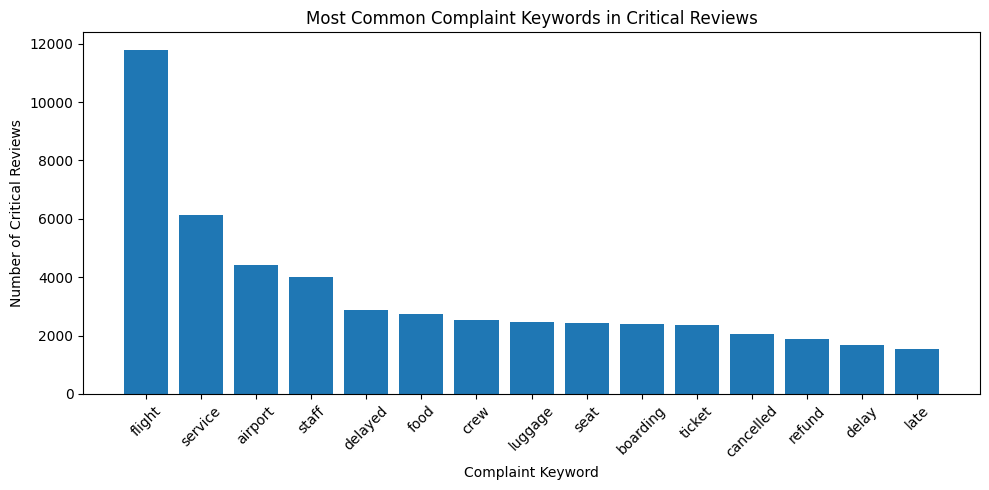

In [74]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_keywords_df["Keyword"],
    top_keywords_df["Review_Count"]
)

plt.title("Most Common Complaint Keywords in Critical Reviews")
plt.xlabel("Complaint Keyword")
plt.ylabel("Number of Critical Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Group similar complaints into categories

Individual keywords can describe the same problem.

For example:

- `delay`, `delayed`, and `late` all relate to flight delays.
- `bag`, `baggage`, and `luggage` relate to baggage.
- `refund` and `compensation` relate to money or compensation.

I will group related keywords into broader complaint categories.

This is still **rule-based Python logic**, not Machine Learning.

In [75]:
complaint_categories = {
    "Flight Delay": [
        "delay", "delayed", "late"
    ],
    "Baggage": [
        "baggage", "bag", "luggage", "suitcase"
    ],
    "Refund / Compensation": [
        "refund", "refunds", "compensation"
    ],
    "Cancellation": [
        "cancel", "cancelled", "cancellation"
    ],
    "Booking / Ticketing": [
        "booking", "ticket"
    ],
    "Seat / Comfort": [
        "seat", "legroom"
    ],
    "Food / Beverage": [
        "food", "meal"
    ],
    "Staff / Customer Service": [
        "crew", "staff", "service", "rude", "unfriendly"
    ],
    "Airport / Boarding": [
        "airport", "boarding"
    ],
    "Flight / Connection": [
        "flight", "connection"
    ]
}

In [76]:
def count_complaint_categories(
    reviews,
    complaint_categories
):
    category_counts = Counter()

    for text in reviews:
        words = set(text.split())

        for category, keywords in complaint_categories.items():
            if any(keyword in words for keyword in keywords):
                category_counts[category] += 1

    return category_counts

In [77]:
category_counts = count_complaint_categories(
    critical_df["Clean_Review"],
    complaint_categories
)

category_df = pd.DataFrame(
    category_counts.items(),
    columns=["Complaint_Category", "Review_Count"]
).sort_values(
    "Review_Count",
    ascending=False
)

display(category_df)

,Complaint_Category,Review_Count
2,Flight / Connection,11859
3,Staff / Customer Service,10166
1,Airport / Boarding,5870
7,Flight Delay,4824
4,Baggage,4239
8,Food / Beverage,3447
0,Booking / Ticketing,3272
6,Cancellation,2689
9,Seat / Comfort,2660
5,Refund / Compensation,2623


### Complaint category chart

This chart gives a broader view of the main problems found in the critical reviews.

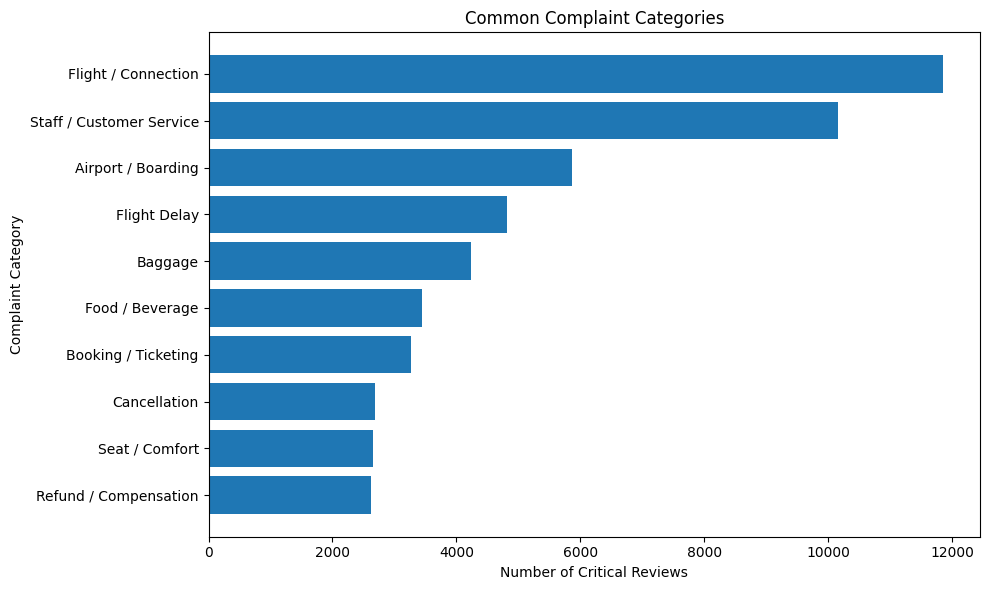

In [78]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_df["Complaint_Category"],
    category_df["Review_Count"]
)

plt.title("Common Complaint Categories")
plt.xlabel("Number of Critical Reviews")
plt.ylabel("Complaint Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Select 3 critical and detailed reviews

The assessment asks for **three of the most critical, detailed negative reviews**.

To keep the selection transparent, I will use a simple priority score:

- lower rating = higher priority
- longer review = more detail

This is only a rule-based score. It is not a Machine Learning model.

In [79]:
critical_df["Review_Length"] = (
    critical_df["Clean_Review"].str.len()
)

critical_df["Priority_Score"] = (
    (3 - critical_df["Rating_5"]) * 100
    + critical_df["Review_Length"].clip(upper=1000) / 10
)

top_3_reviews = critical_df.sort_values(
    "Priority_Score",
    ascending=False
).head(3).copy()

display(
    top_3_reviews[
        [
            "Airline Name",
            "Overall_Rating",
            "Rating_5",
            "Review_Title",
            "Review",
            "Priority_Score"
        ]
    ]
)

,Airline Name,Overall_Rating,Rating_5,Review_Title,Review,Priority_Score
23164,ZIPAIR,1.0,1,"""$300 savings was absolutely not worth it""",My issues started before we even flew. I rec...,300.0
23162,ZIPAIR,1.0,1,"""the visa I did not have""",This is the worst service I have ever receive...,300.0
23142,ZIPAIR,1.0,1,"""I recommend ZIPAIR""",I recommend ZIPAIR. My friend and I booked a...,300.0


### Why these three reviews?

These three cases were selected because they combine a very low rating with a more detailed review.

This gives the Generative AI model enough information to understand the customer's problem and write a more specific response.

# 15. Generative AI — Google Gemini

The final part of the project uses Generative AI to create customer-support responses.

I will use Google Gemini to generate a short, personalized and empathetic apology email for each of the three selected reviews.

The API will receive the customer's review text and instructions describing the required response.

In [80]:
%pip install google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [81]:
import os
from google import genai

In [82]:
api_key = "GEMINI_API_KEY"

In [83]:
client = genai.Client(api_key=api_key)

print("Gemini client created successfully.")

Gemini client created successfully.


## 16. Creating the Customer Support Prompt

The prompt instructs Gemini to behave as a professional customer support agent.

The generated response should:

- Address the customer's specific complaint
- Show empathy
- Apologize professionally
- Remain concise
- Avoid inventing compensation or promises

In [84]:
def create_prompt(review):
    return f"""
You are a professional airline customer support agent.

Read the following customer review and write a short,
personalized and empathetic apology email.

Requirements:
- Acknowledge the customer's specific complaint.
- Show empathy.
- Apologize professionally.
- Do not invent compensation or promises.
- Keep the email concise.
- Use a professional customer-service tone.

Customer Review:
{review}

Write only the email response.
"""

In [85]:
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini-3.1-flash-tts-preview
models/

In [91]:
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents="Write one short sentence saying hello."
)

print(response.text)

Hello, it is a pleasure to meet you.


In [ ]:
## 18. Generating Responses for the Three Selected Reviews

The Gemini API will now be called for each of the three selected critical reviews.

The generated responses are stored in a Python list so they can be displayed together at the end of the notebook.

In [89]:
generated_emails = []

for _, row in top_3_reviews.iterrows():

    prompt = create_prompt(row["Review"])

    response = client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt
    )

    generated_emails.append(response.text)

In [90]:
for i, email in enumerate(generated_emails, start=1):
    print("=" * 70)
    print(f"AI-GENERATED RESPONSE {i}")
    print("=" * 70)
    print(email)
    print()

AI-GENERATED RESPONSE 1
Subject: Apology regarding your recent ZIPAIR experience

Dear Valued Guest,

Thank you for taking the time to share your feedback regarding your recent flight with us. I am sincerely sorry for the stress and frustration you experienced throughout your journey. 

I understand how distressing it was to receive conflicting and delayed information regarding your Covid recovery documentation prior to your departure. You should have been provided with clear, consistent guidance, and I apologize for the anxiety this caused. Additionally, I am sorry for the miscommunication regarding the TSA PreCheck at the check-in counter, as well as the disappointments you encountered onboard with the timing of our meal service and the non-functional inflight entertainment system. 

We strive to provide a seamless and comfortable experience for our passengers, and it is clear we fell short in several areas during your trip. Please be assured that your detailed feedback has been shar


# 19. Conclusion

I developed a simple customer feedback analysis and automated response system.

Pandas was used for data preparation and cleaning. Rule-based Python logic was used to identify critical reviews, and Python's `Counter` was used to find common complaint keywords.

Finally, Google Gemini was used to generate personalized and empathetic responses for three selected critical reviews.

The project combines basic data analysis with Generative AI to demonstrate how customer feedback can be processed and responded to more efficiently.